# 02 — Germany 2018 renewable-resource exploratory analysis

**Question.** What are the characteristic wind and solar patterns in Germany during 2018,
and what does the raw daily variability look like before we ask any portfolio questions?

This notebook uses the pre-computed 2018 country time series and the spatial annual / seasonal
mean maps. It uses the **area-weighted resource proxy**; notebook 04 validates it against
SMARD, and notebook 05 adds the capacity-weighted modelled fleet proxy. It is Germany-only
because the simple power-law wind extrapolation is not reliable in the Alps and the literature
on Dunkelflaute is dominated by the German case.

## 1. Concepts used in this notebook

**Capacity factor (CF)** is actual energy produced divided by the energy that would be
produced if the same capacity ran at rated power for the whole period:

$$CF = \frac{E}{P_{rated}\,\Delta t}.$$

A daily CF of 0.25 means that the fleet produced one quarter of its maximum possible daily
energy. CF is dimensionless and lies between 0 and 1. Here, `wind_cf` and `solar_cf` are
**meteorology-derived resource proxies**, not measured fleet CFs: every German grid-cell
centre is area-weighted equally after a latitude correction, irrespective of where plants
are actually installed.

The **50/50 hybrid CF** is

$$CF_{hybrid}=0.5CF_{wind}+0.5CF_{solar}.$$

The weights describe shares of total rated portfolio capacity, not shares of annual energy.
Consequently, hybrid CF is a normalized portfolio output—not an additional physical plant.

## 2. Load the data

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from cosmo_rea6_pipeline import build_country_masks

ASSETS = ROOT / "app_assets" / "2018"
daily_all = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_daily_country_timeseries.parquet")
germany = daily_all[daily_all["country"] == "de"].copy()
germany = germany.sort_values("time").reset_index(drop=True)

annual = xr.open_dataset(ASSETS / "cosmo_rea6_dach_2018_annual_means.nc")
seasonal = xr.open_dataset(ASSETS / "cosmo_rea6_dach_2018_seasonal_means.nc")
masks = build_country_masks(annual)

de_cells = int(masks["mask_de"].sum())
qc = pd.Series({
    "unique dates": germany["time"].nunique(),
    "missing analysis values": int(germany[["wind_cf", "solar_cf", "combined_cf", "ghi"]].isna().sum().sum()),
    "minimum CF": germany[["wind_cf", "solar_cf", "combined_cf"]].min().min(),
    "maximum CF": germany[["wind_cf", "solar_cf", "combined_cf"]].max().max(),
    "German model grid cells": de_cells,
}, name="pre-analysis check")
display(qc)
print(germany[["time", "wind_cf", "solar_cf", "combined_cf", "ghi", "wspd100"]].head())

unique dates                365.000000
missing analysis values       0.000000
minimum CF                    0.000512
maximum CF                    0.816801
German model grid cells    9530.000000
Name: pre-analysis check, dtype: float64

                 time   wind_cf  solar_cf  combined_cf        ghi   wspd100
0 2018-01-01 01:00:00  0.474925  0.029231     0.252078  27.108017  7.267401
1 2018-01-02 01:00:00  0.305378  0.019929     0.162653  18.364670  5.736770
2 2018-01-03 01:00:00  0.734878  0.016999     0.375938  15.765672  9.697816
3 2018-01-04 01:00:00  0.463363  0.012565     0.237964  11.665102  7.169491
4 2018-01-05 01:00:00  0.335739  0.018023     0.176881  16.782420  5.993490


**Before interpreting figures.** The 365 unique dates confirm complete non-leap-year coverage;
zero missing values and CF values inside 0–1 are basic integrity checks. The cell count refers
to reanalysis grid centres inside Germany, not observations or plants.

**GHI** (global horizontal irradiance) is direct horizontal plus diffuse horizontal shortwave
irradiance, in W m⁻². It describes solar energy arriving per second on a horizontal square metre.
The solar CF converts daily-mean GHI and temperature with a deliberately simple proxy. It omits
panel tilt, orientation, shading, snow, inverter clipping, and fleet location, so it is not
measured PV output. Example: a proxy CF of 0.20 means 20% of rated output over that day; it does
not mean GHI itself was 20%.

## 3. Daily distributions and CDFs

These are the empirical distributions of capacity factors over Germany in 2018. The wind
distribution is right-skewed, the solar distribution is bounded at zero with a long upper tail,
and the combined series is less extreme than either on its own.

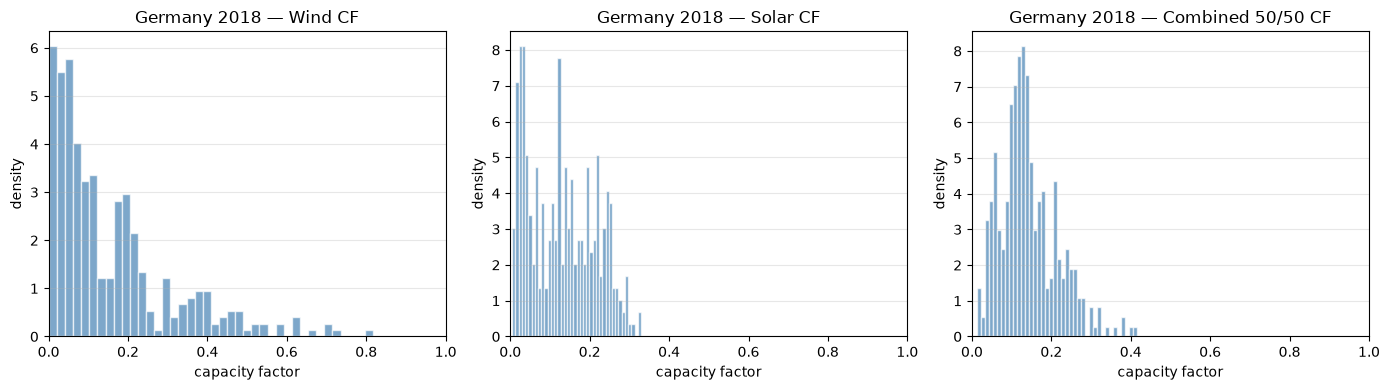

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols = ["wind_cf", "solar_cf", "combined_cf"]
titles = ["Wind CF", "Solar CF", "Combined 50/50 CF"]

for ax, col, title in zip(axes, cols, titles):
    ax.hist(germany[col], bins=40, density=True, alpha=0.7, color="steelblue", edgecolor="white")
    ax.set_xlabel("capacity factor")
    ax.set_ylabel("density")
    ax.set_title(f"Germany 2018 — {title}")
    ax.set_xlim(0, 1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Cumulative distribution functions

CDFs make the tails visible. The 5th and 10th percentiles describe the low-output tail used
later for Dunkelflaute screening and portfolio sensitivity.

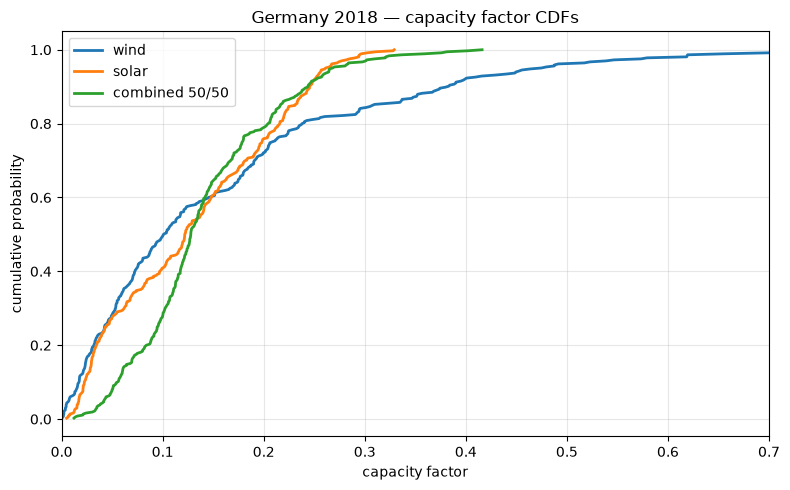

,wind_cf,solar_cf,combined_cf
0.05,0.008,0.017,0.042
0.10,0.017,0.023,0.056
0.50,0.101,0.122,0.128
0.90,0.382,0.246,0.244


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for col, label in zip(["wind_cf", "solar_cf", "combined_cf"], ["wind", "solar", "combined 50/50"]):
    sorted_data = np.sort(germany[col].values)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label, linewidth=2)

ax.set_xlabel("capacity factor")
ax.set_ylabel("cumulative probability")
ax.set_title("Germany 2018 — capacity factor CDFs")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 0.7)
plt.tight_layout()
plt.show()

q = germany[["wind_cf", "solar_cf", "combined_cf"]].quantile([0.05, 0.1, 0.5, 0.9]).round(3)
q

## 5. Annual cycle with interquartile bands

Monthly means alone hide the spread. The shaded band shows the middle 50% of daily values.

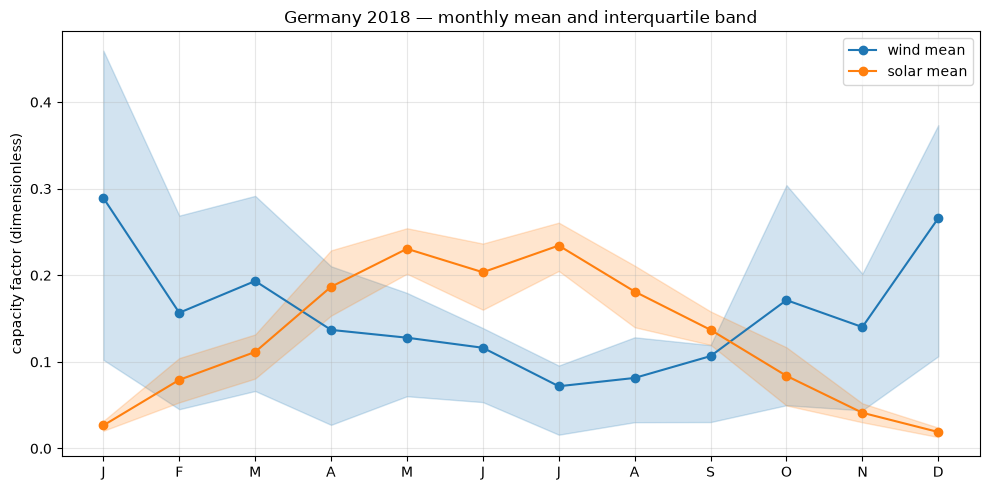

In [4]:
germany["month"] = germany["time"].dt.month
monthly = germany.groupby("month").agg(
    wind_mean=("wind_cf", "mean"),
    wind_q25=("wind_cf", lambda x: x.quantile(0.25)),
    wind_q75=("wind_cf", lambda x: x.quantile(0.75)),
    solar_mean=("solar_cf", "mean"),
    solar_q25=("solar_cf", lambda x: x.quantile(0.25)),
    solar_q75=("solar_cf", lambda x: x.quantile(0.75)),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["month"], monthly["wind_mean"], "o-", color="#1f77b4", label="wind mean")
ax.fill_between(monthly["month"], monthly["wind_q25"], monthly["wind_q75"], color="#1f77b4", alpha=0.2)
ax.plot(monthly["month"], monthly["solar_mean"], "o-", color="#ff7f0e", label="solar mean")
ax.fill_between(monthly["month"], monthly["solar_q25"], monthly["solar_q75"], color="#ff7f0e", alpha=0.2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("capacity factor (dimensionless)")
ax.set_title("Germany 2018 — monthly mean and interquartile band")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**How to read this figure.** Compare each line's seasonal level and the width of its shaded
band. The line is a monthly mean; the band is day-to-day spread, not uncertainty in the mean.
Opposite seasonal movement suggests complementarity, but does not prove that both cannot be
low together.

## 6. Persistence: autocorrelation and low-resource run lengths

Day-to-day persistence is expected in mid-latitude weather, while daily solar means can remain
correlated across multi-day cloudy periods. Atmospheric blocking can provide physical context
for some prolonged low-wind episodes, but this notebook does not diagnose circulation regimes
or attribute individual events to blocking.

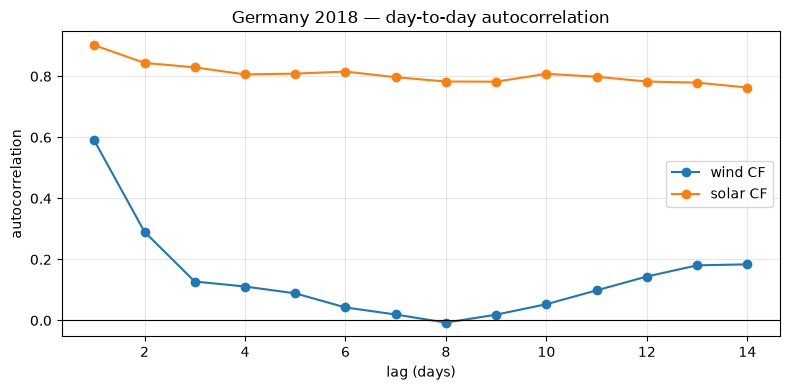

In [5]:
max_lag = 14
lags = range(1, max_lag + 1)
wind_ac = [germany["wind_cf"].autocorr(lag=lag) for lag in lags]
solar_ac = [germany["solar_cf"].autocorr(lag=lag) for lag in lags]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, wind_ac, "o-", label="wind CF")
ax.plot(lags, solar_ac, "o-", label="solar CF")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("lag (days)")
ax.set_ylabel("autocorrelation")
ax.set_title("Germany 2018 — day-to-day autocorrelation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Low-wind and low-solar spell-length distributions

A "spell" is a sequence of consecutive days below the 10th percentile of the respective
variable. The distribution describes persistence in this one-year resource proxy; implications
for storage cannot be inferred without demand, system, and storage modelling.

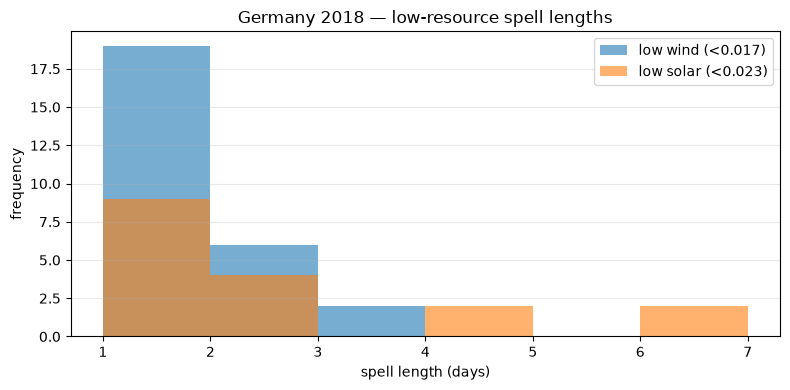

,low-wind spells,low-solar spells
count,27.00000,17.000000
max length,3.00000,6.000000
mean length,1.37037,2.176471


In [6]:
def run_lengths(series, threshold):
    flags = (series < threshold).astype(int)
    runs = []
    current = 0
    for value in flags:
        if value:
            current += 1
        else:
            if current > 0:
                runs.append(current)
            current = 0
    if current > 0:
        runs.append(current)
    return pd.Series(runs) if runs else pd.Series(dtype=int)

wind_thr = germany["wind_cf"].quantile(0.1)
solar_thr = germany["solar_cf"].quantile(0.1)
wind_runs = run_lengths(germany["wind_cf"], wind_thr)
solar_runs = run_lengths(germany["solar_cf"], solar_thr)

fig, ax = plt.subplots(figsize=(8, 4))
max_len = max(wind_runs.max() if len(wind_runs) else 0, solar_runs.max() if len(solar_runs) else 0, 1)
bins = range(1, max_len + 2)
ax.hist(wind_runs, bins=bins, alpha=0.6, label=f"low wind (<{wind_thr:.3f})")
ax.hist(solar_runs, bins=bins, alpha=0.6, label=f"low solar (<{solar_thr:.3f})")
ax.set_xlabel("spell length (days)")
ax.set_ylabel("frequency")
ax.set_title("Germany 2018 — low-resource spell lengths")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

spell_stats = pd.DataFrame({
    "low-wind spells": [len(wind_runs), int(wind_runs.max() if len(wind_runs) else 0), float(wind_runs.mean() if len(wind_runs) else 0)],
    "low-solar spells": [len(solar_runs), int(solar_runs.max() if len(solar_runs) else 0), float(solar_runs.mean() if len(solar_runs) else 0)],
}, index=["count", "max length", "mean length"])
spell_stats

## 8. North vs. south Germany spatial split

Germany's wind resource is concentrated in the north, the solar resource in the south. We
split the country at 51°N and report area-weighted annual and seasonal means for both halves.

In [7]:
def area_mean(da, mask):
    lat = da.latitude
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(mask)
    weights = weights / weights.sum()
    return float((da * weights).sum().values)

de_mask = masks["mask_de"]
north_mask = de_mask & (annual.latitude > 51)
south_mask = de_mask & (annual.latitude <= 51)

rows = []
for ds, label in [(annual, "annual"), (seasonal, "seasonal")]:
    if label == "annual":
        rows.append({
            "period": "annual",
            "north_wind_cf": area_mean(ds["wind_cf"], north_mask),
            "north_solar_cf": area_mean(ds["solar_cf"], north_mask),
            "south_wind_cf": area_mean(ds["wind_cf"], south_mask),
            "south_solar_cf": area_mean(ds["solar_cf"], south_mask),
        })
    else:
        for season in ds["season"].values:
            s = ds.sel(season=season)
            rows.append({
                "period": season,
                "north_wind_cf": area_mean(s["wind_cf"], north_mask),
                "north_solar_cf": area_mean(s["solar_cf"], north_mask),
                "south_wind_cf": area_mean(s["wind_cf"], south_mask),
                "south_solar_cf": area_mean(s["solar_cf"], south_mask),
            })

ns_table = pd.DataFrame(rows).round(3).set_index("period")
ns_table

,north_wind_cf,north_solar_cf,south_wind_cf,south_solar_cf
period,,,,
annual,0.189,0.125,0.120,0.131
DJF,0.254,0.038,0.220,0.045
MAM,0.189,0.175,0.116,0.177
JJA,0.129,0.204,0.050,0.209
SON,0.183,0.081,0.094,0.094


## 9. Seasonal spatial maps of wind and solar

The maps emphasize the north–south contrast. Only grid-cell centres inside the German
political boundary are shown.

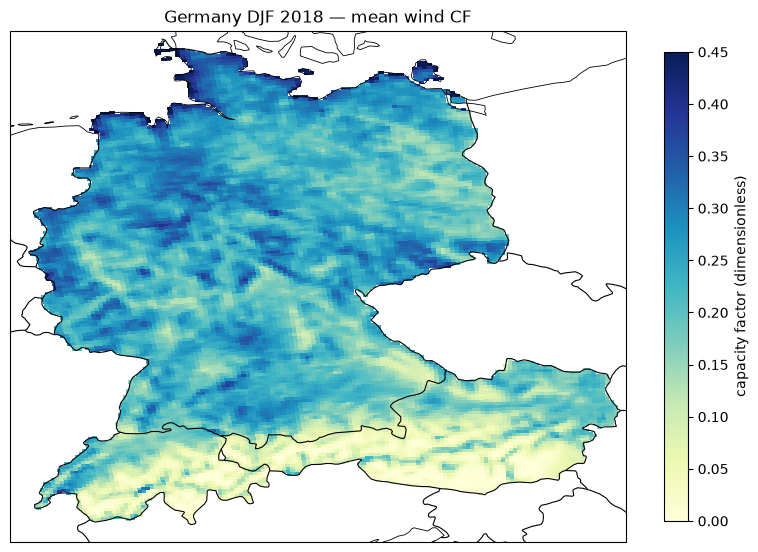

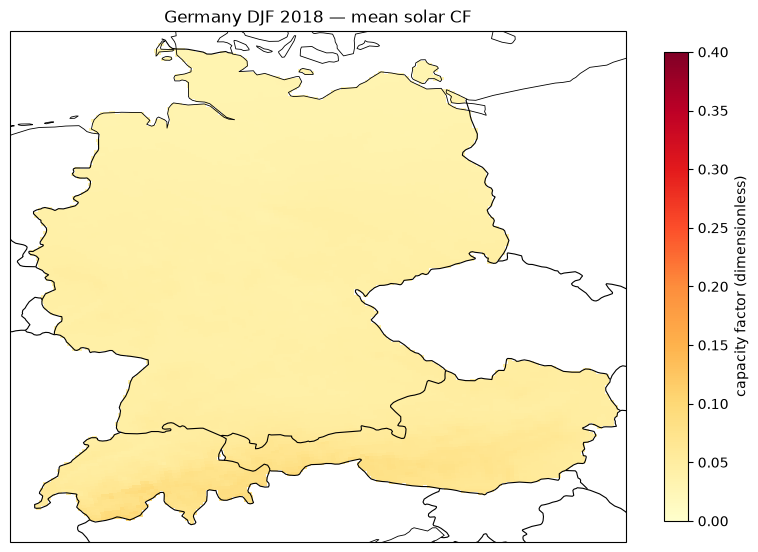

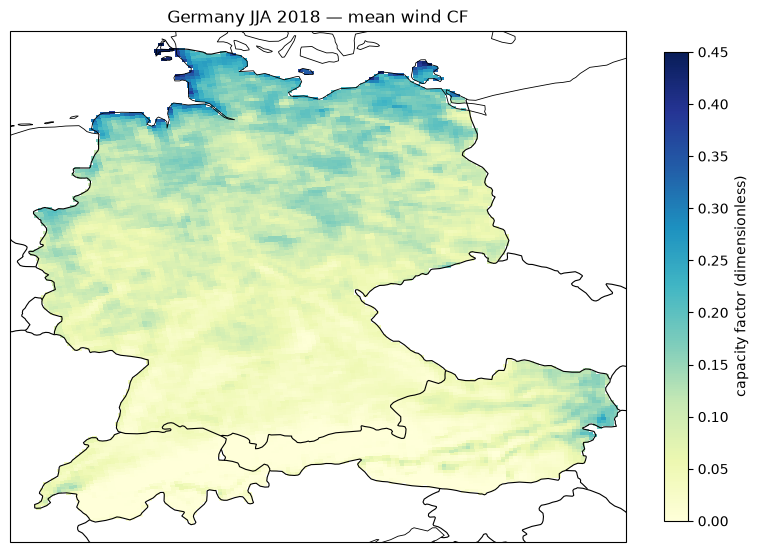

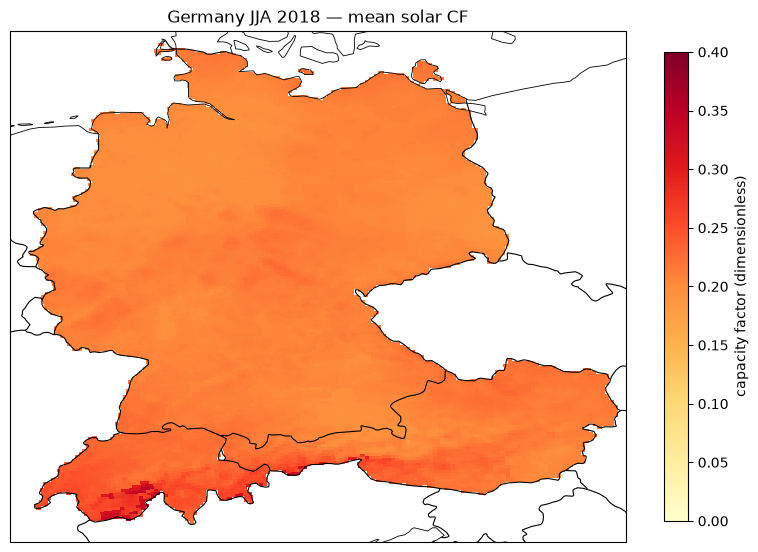

In [8]:
def plot_germany_field(ds, var, cmap, title, vmin, vmax):
    fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    im = ax.pcolormesh(
        ds.longitude, ds.latitude, ds[var],
        shading="auto", cmap=cmap, transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
    )
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.8, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="black")
    ax.set_extent([5.5, 17.25, 45.5, 55.25], crs=ccrs.PlateCarree())
    ax.set_title(title)
    unit_label = "capacity factor (dimensionless)" if var.endswith("_cf") else "GHI (W m⁻²)"
    plt.colorbar(im, ax=ax, shrink=0.7, label=unit_label)
    plt.tight_layout()
    plt.show()

for season in ["DJF", "JJA"]:
    s = seasonal.sel(season=season)
    plot_germany_field(s, "wind_cf", "YlGnBu", f"Germany {season} 2018 — mean wind CF", 0, 0.45)
    plot_germany_field(s, "solar_cf", "YlOrRd", f"Germany {season} 2018 — mean solar CF", 0, 0.4)

## 10. Wind vs. solar joint distributions by season

This is the most direct visualisation of complementarity: do high-wind days coincide with
low-solar days, and vice versa?

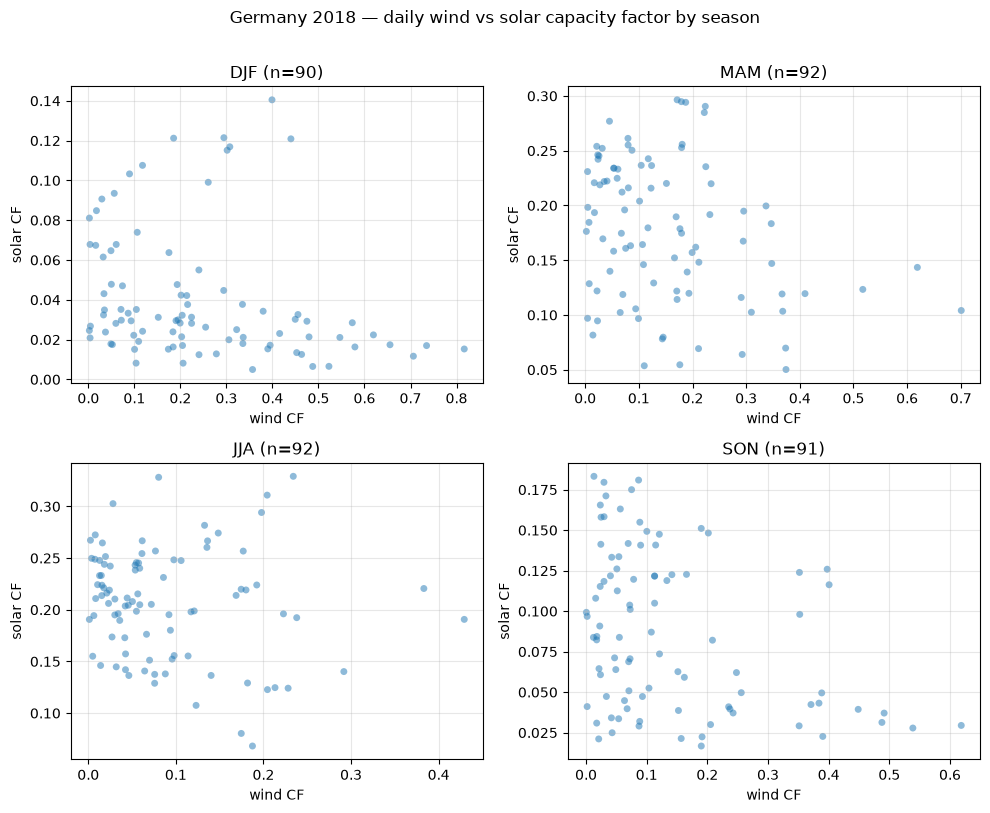

In [9]:
month_to_season = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}
germany["season"] = germany["time"].dt.month.map(month_to_season)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, season in zip(axes.flat, ["DJF", "MAM", "JJA", "SON"]):
    sub = germany[germany["season"] == season]
    ax.scatter(sub["wind_cf"], sub["solar_cf"], alpha=0.5, s=25, edgecolor="none")
    ax.set_xlabel("wind CF")
    ax.set_ylabel("solar CF")
    ax.set_title(f"{season} (n={len(sub)})")
    ax.grid(alpha=0.3)

fig.suptitle("Germany 2018 — daily wind vs solar capacity factor by season", y=1.01)
plt.tight_layout()
plt.show()

## Key EDA take-aways

- Wind and solar have opposite seasonal cycles: wind peaks in winter, solar in summer.
- Daily distributions are non-Gaussian; wind has a long upper tail and both have many near-zero days.
- Autocorrelation dies out after 3–5 days, but individual low-resource spells can last much longer.
- The north–south split confirms that Germany's resource is spatially heterogeneous; a single national mean hides strong gradients.
- The wind–solar scatter shows negative association in all seasons, which is the basis for the complementarity analysis in the next notebook.